In [39]:
import pandas as pd
import numpy as np
from datetime import datetime

from setting_for_sda.path_setting import path_list
from setting_for_sda.date_setting import Date_Setting


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.visualization.distribution_collector import calc_top_mid_bottom_tags_prop
from matplotlib import pyplot as plt
from lib.visualization.plot_generator import PlotGen

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()

import statsmodels.formula.api as smf
from scipy import stats



Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [2]:
idx = 0
tot_top_df = pd.DataFrame()
tot_mid_df = pd.DataFrame()
tot_bot_df = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] drawing figures for {lang} language')
    visualization_target = f'run_id_{100+idx}'
    model_in_run = 'tag'
    output_dir = './fig/'
    date_range = 'Weekly'
    viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
    data_dir = f"{viz_dir}/data"
    option_dict = load_json(f"{viz_dir}/option.json")
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    df = load_df(data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")
    df['rel_week'] = np.floor((df['cdate']-std_date).dt.days/7)
    proportion_dict = calc_top_mid_bottom_tags_prop(df, pct_cut=0.2)

    for label, tot_df_name in [('Top 20% Tags', 'top'), ('Middle 60% Tags', 'mid'), ('Bottom 20% Tags', 'bot')]:
        df_sub = pd.concat(
            [pd.Series([lang] * len(proportion_dict[label]),
                        name='language').reset_index(drop=True),
             proportion_dict[label].reset_index(drop=True)],
            axis=1
        )
        if label.startswith('Top'):
            tot_top_df = pd.concat([tot_top_df, df_sub], axis=0)
        elif label.startswith('Middle'):
            tot_mid_df = pd.concat([tot_mid_df, df_sub], axis=0)
        else:
            tot_bot_df = pd.concat([tot_bot_df, df_sub], axis=0)

    print(f'[End....] drawing figures for {lang} language')

[Start....] drawing figures for python language
[End....] drawing figures for python language
[Start....] drawing figures for javascript language
[End....] drawing figures for javascript language
[Start....] drawing figures for java language


KeyboardInterrupt: 

In [3]:
def check_parallel_trends(df):
# 사전 시기 데이터로 추세 확인
    pre_df = df[df['rel_week'] < 0].copy()

    # 언어별 사전 추세 시각화
    fig, ax = plt.subplots(figsize=(10, 6))
    for lang in df['language'].unique():
        lang_data = pre_df[pre_df['language'] == lang]
        lang_data_grouped = lang_data.groupby('rel_week')['pct_pct'].mean()
        ax.plot(lang_data_grouped.index, lang_data_grouped.values, 
                label=lang, marker='o')

    ax.axvline(x=0, color='red', linestyle='--', label='Treatment')
    ax.legend()
    ax.set_xlabel('Relative Week')
    ax.set_ylabel('Percentage')
    ax.set_title('Parallel Trends Check')
    plt.show()

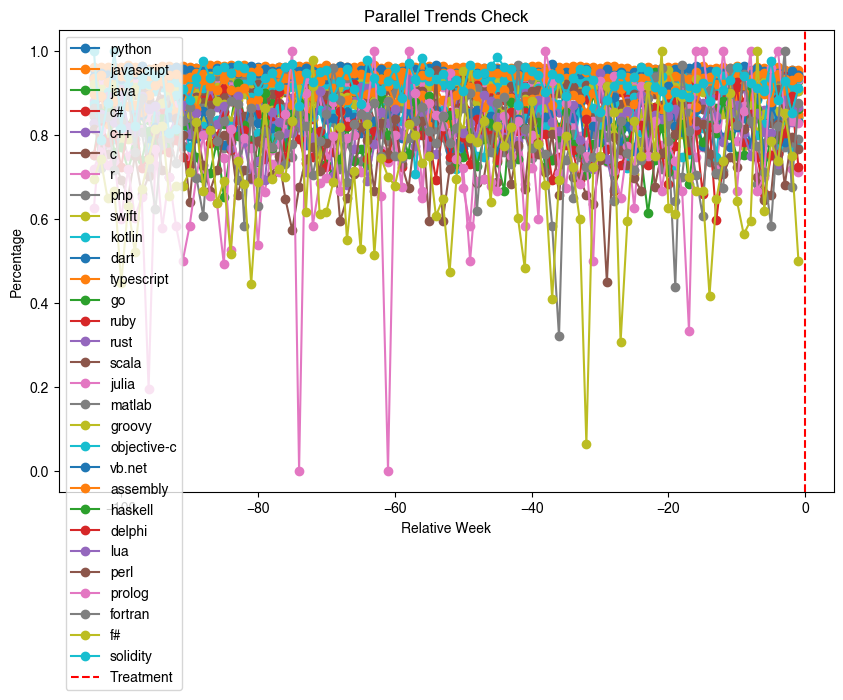

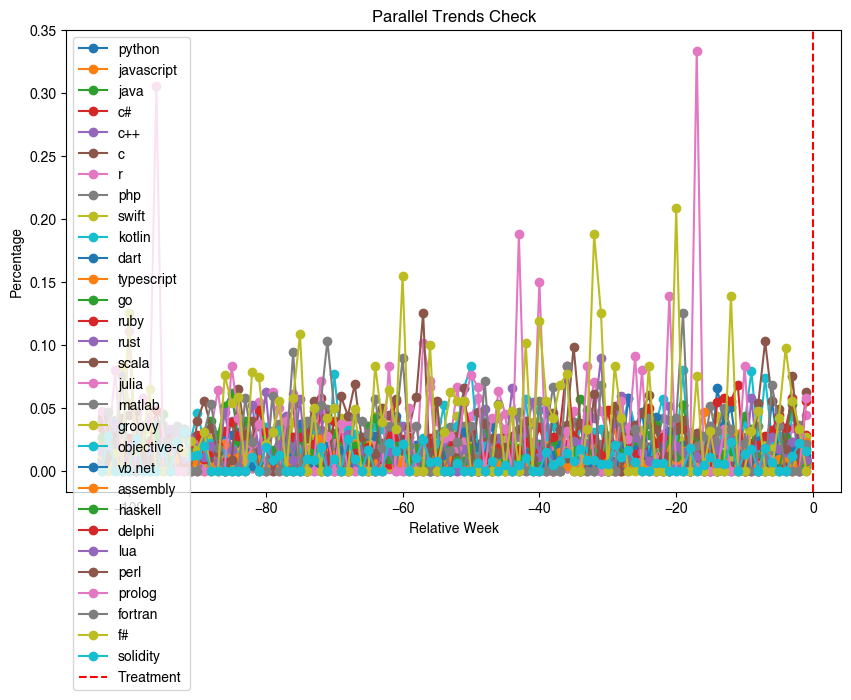

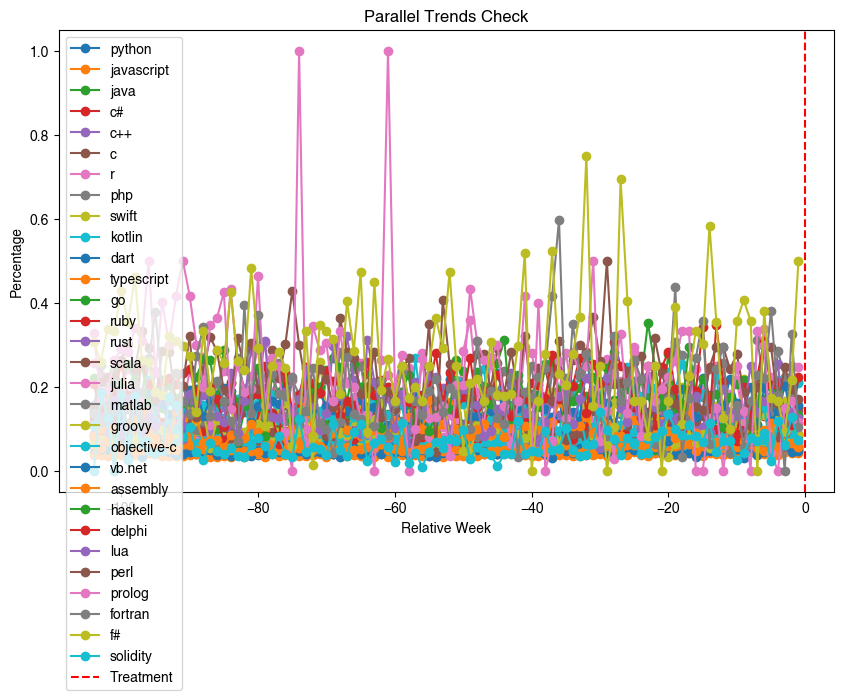

In [4]:
check_parallel_trends(tot_top_df)
check_parallel_trends(tot_bot_df)
check_parallel_trends(tot_mid_df)

In [5]:
def conduct_DID_corrected(df):
    df = df.copy()
    df['post'] = (df['rel_week'] >= 0).astype(int)
    
    # 각 언어별로 직접 DID 효과 추정
    model = smf.ols(
        'pct_pct ~ 0 + C(language) + C(language):rel_week + '
        'C(language):post + C(language):rel_week:post',
        data=df
    ).fit()
    
    results = []
    languages = df['language'].unique()
    
    for lang in languages:
        # DID 계수 직접 추출
        term = f'C(language)[{lang}]:rel_week:post'
        effect = model.params.get(term, 0)
        se = np.sqrt(model.cov_params().loc[term, term])
        
        # 95% CI
        low = effect - 1.96 * se
        high = effect + 1.96 * se
        
        results.append({
            'language': lang,
            'effect': effect,
            'low': low,
            'high': high,
            'se': se,
            'pvalue': 2 * (1 - stats.norm.cdf(abs(effect / se)))
        })
    
    effect_df = pd.DataFrame(results).sort_values('effect')
    
    # 다중비교 보정 (Bonferroni)
    effect_df['pvalue_bonf'] = np.minimum(
        effect_df['pvalue'] * len(languages), 
        1.0
    )
    
    return effect_df

In [6]:
top_effect_df = conduct_DID_corrected(tot_top_df)
bot_effect_df = conduct_DID_corrected(tot_bot_df)
mid_effect_df = conduct_DID_corrected(tot_mid_df)

In [7]:
import matplotlib.pyplot as plt

def plot_effect(effect_df):
    # 효과 크기로 정렬 (이미 되어있다면 생략 가능)
    effect_df = effect_df.sort_values('effect')
    
    plt.figure(figsize=(8, 10))
    
    # 에러바 플롯
    plt.errorbar(
        effect_df['effect'],
        range(len(effect_df)),  # y축을 인덱스로
        xerr=[
            effect_df['effect'] - effect_df['low'],
            effect_df['high'] - effect_df['effect']
        ],
        fmt='o',
        capsize=5,  # 에러바 끝 막대
        markersize=6,
        elinewidth=2,
        capthick=2
    )
    
    # 0 기준선 (효과 없음)
    plt.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # y축 레이블 설정
    plt.yticks(range(len(effect_df)), effect_df['language'])
    
    # 유의성 표시 (선택사항)
    for idx, row in enumerate(effect_df.itertuples()):
        if hasattr(row, 'pvalue') and row.pvalue < 0.05:
            plt.text(row.effect, idx, '*', 
                    fontsize=16, ha='center', va='bottom')
        elif hasattr(row, 'pvalue_bonf') and row.pvalue_bonf < 0.05:
            plt.text(row.effect, idx, '*', 
                    fontsize=16, ha='center', va='bottom')
    
    plt.xlabel('DID Effect (Slope change)', fontsize=12)
    plt.ylabel('Language', fontsize=12)
    plt.title('Treatment Effect by Language\n(95% Confidence Intervals)', 
              fontsize=13, pad=15)
    
    plt.grid(axis='x', alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()

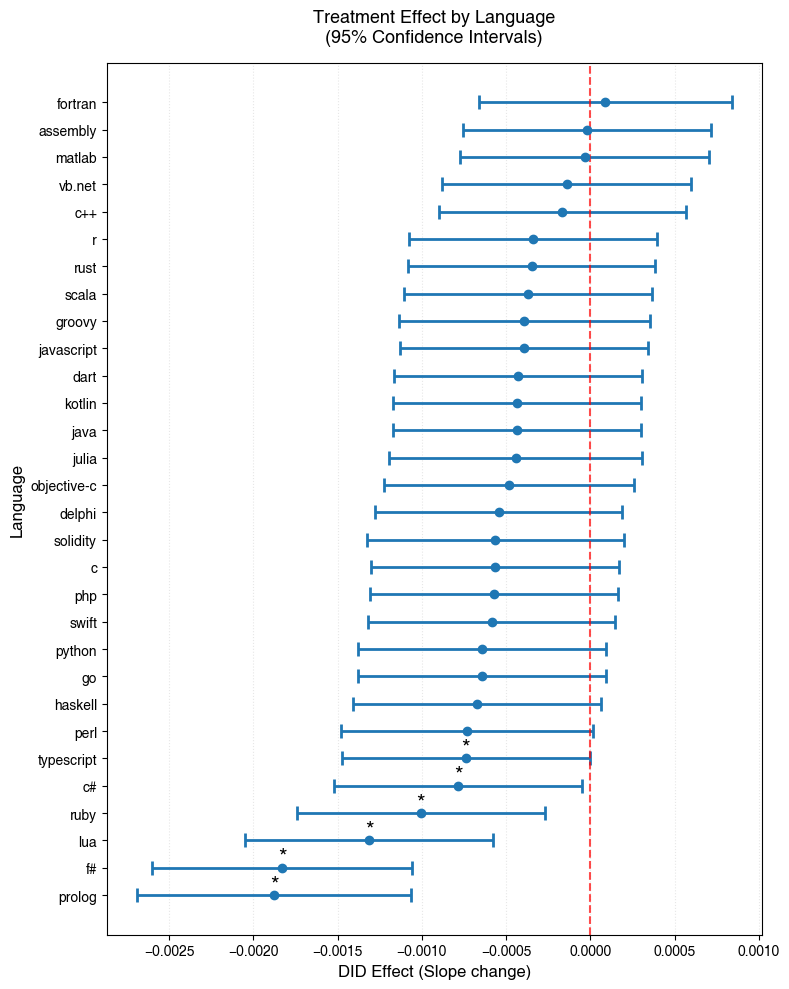

In [8]:
plot_effect(top_effect_df)

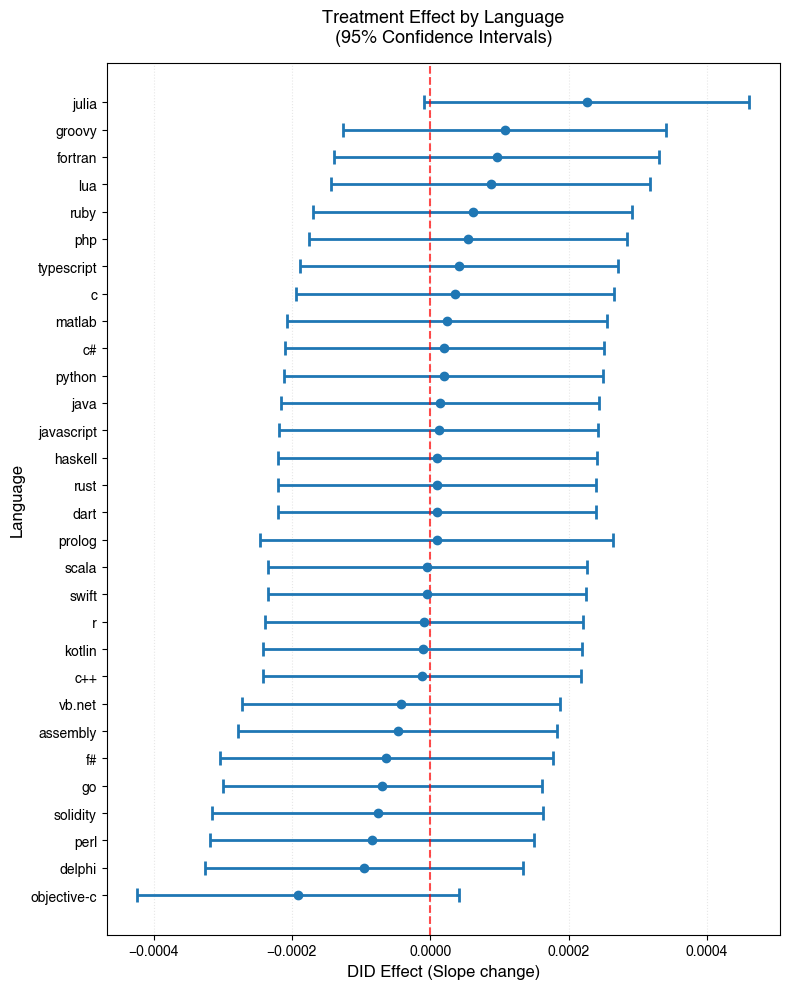

In [9]:
plot_effect(bot_effect_df)

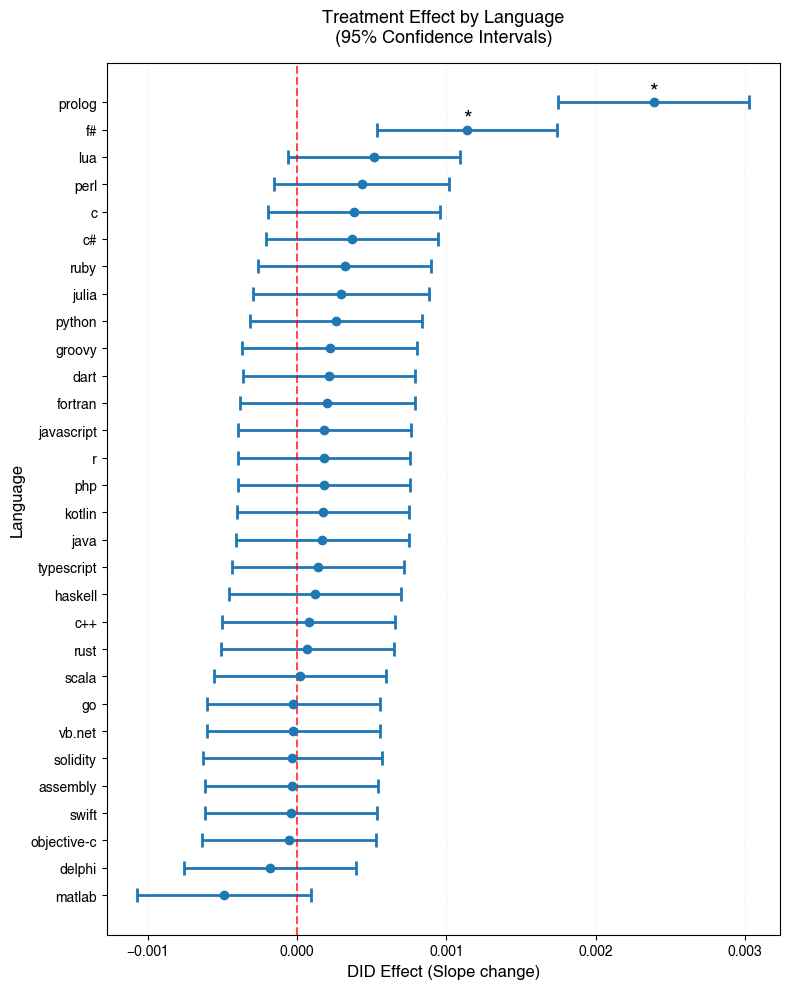

In [10]:
plot_effect(mid_effect_df)

<Axes: xlabel='effect', ylabel='Density'>

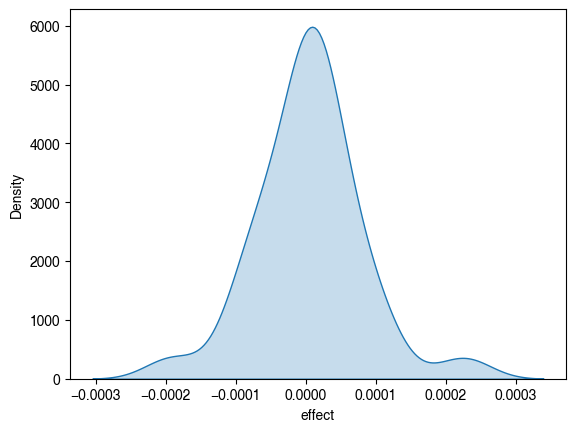

In [11]:
import seaborn as sns
sns.kdeplot(bot_effect_df['effect'], fill=True)

<Axes: xlabel='effect', ylabel='Density'>

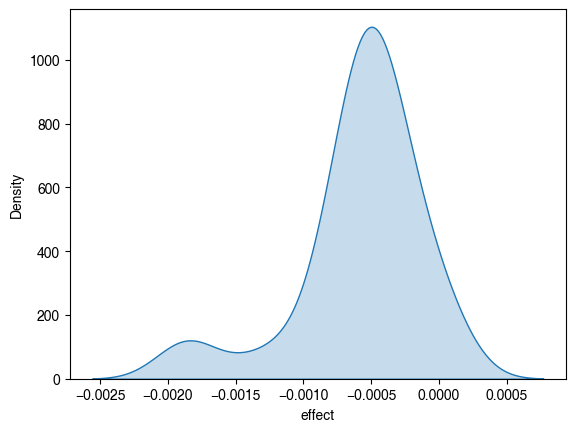

In [12]:
import seaborn as sns
sns.kdeplot(top_effect_df['effect'], fill=True)

In [13]:
from statsmodels.regression.mixed_linear_model import MixedLM

def hierarchical_did(df, tag_group_name):
    """
    Hierarchical/Mixed Effects DID
    - Fixed effect: 전체 평균 DID 효과
    - Random effect: 언어별 deviation
    """
    df = df.copy()
    df['post'] = (df['rel_week'] >= 0).astype(int)
    df['rel_week_post'] = df['rel_week'] * df['post']
    
    # Mixed effects model
    # Fixed: rel_week, post, rel_week:post
    # Random: language-specific intercepts and slopes
    model = MixedLM.from_formula(
        'pct_pct ~ rel_week + post + rel_week_post',
        data=df,
        groups=df['language'],
        re_formula='~rel_week + post + rel_week_post'
    )
    
    result = model.fit(method='lbfgs')
    
    print(f"\n=== {tag_group_name} - Hierarchical DID ===")
    print(result.summary())
    
    # 언어별 random effects 추출
    random_effects = result.random_effects
    
    # 언어별 total effect = fixed + random
    fixed_did = result.fe_params['rel_week_post']
    
    lang_effects = []
    for lang, re in random_effects.items():
        total_effect = fixed_did + re.get('rel_week_post', 0)
        lang_effects.append({
            'language': lang,
            'fixed_effect': fixed_did,
            'random_effect': re.get('rel_week_post', 0),
            'total_effect': total_effect
        })
    
    return result, pd.DataFrame(lang_effects)

# 실행
result_top, lang_effects_top = hierarchical_did(tot_top_df, 'Top 20%')
result_bot, lang_effects_bot = hierarchical_did(tot_bot_df, 'Bottom 20%')
result_mid, lang_effects_mid = hierarchical_did(tot_mid_df, 'Middle 20%')

/home/mghan/sopjt/git/so_data_availability/venv_so_data_availability/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mghan/sopjt/git/so_data_availability/venv_so_data_availability/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)



=== Top 20% - Hierarchical DID ===
                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      pct_pct  
No. Observations:       7628         Method:                  REML     
No. Groups:             30           Scale:                   0.0101   
Min. group size:        203          Log-Likelihood:          6252.0498
Max. group size:        260          Converged:               Yes      
Mean group size:        254.3                                          
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     0.866    0.009 92.515 0.000  0.847  0.884
rel_week                      0.000    0.013  0.004 0.997 -0.025  0.025
post                         -0.035    0.010 -3.716 0.000 -0.054 -0.017
rel_week_post                -0.001    0.013 

/home/mghan/sopjt/git/so_data_availability/venv_so_data_availability/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/mghan/sopjt/git/so_data_availability/venv_so_data_availability/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



=== Bottom 20% - Hierarchical DID ===
                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      pct_pct   
No. Observations:      7628         Method:                  REML      
No. Groups:            30           Scale:                   0.0010    
Min. group size:       203          Log-Likelihood:          15453.1466
Max. group size:       260          Converged:               Yes       
Mean group size:       254.3                                           
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     0.014    0.001 10.172 0.000  0.011  0.017
rel_week                      0.000    0.000  0.311 0.756 -0.000  0.000
post                         -0.001    0.002 -0.736 0.462 -0.004  0.002
rel_week_post                 0.000    0.0

/home/mghan/sopjt/git/so_data_availability/venv_so_data_availability/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mghan/sopjt/git/so_data_availability/venv_so_data_availability/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)



=== Middle 20% - Hierarchical DID ===
                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      pct_pct  
No. Observations:       7628         Method:                  REML     
No. Groups:             30           Scale:                   0.0062   
Min. group size:        203          Log-Likelihood:          8223.7649
Max. group size:        260          Converged:               Yes      
Mean group size:        254.3                                          
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     0.120    0.008 15.229 0.000  0.105  0.136
rel_week                     -0.000    0.001 -0.040 0.968 -0.003  0.002
post                         -0.026    0.005 -4.782 0.000 -0.037 -0.015
rel_week_post                 0.000    0.0

In [14]:
from scipy import stats
import numpy as np
import pandas as pd

def comprehensive_meta_analysis(df, tag_group_name):
    """
    Complete meta-analysis with publication bias tests
    """
    # Step 1: 각 언어별 DID 추정
    individual_results = []
    
    for lang in df['language'].unique():
        lang_df = df[df['language'] == lang].copy()
        lang_df['post'] = (lang_df['rel_week'] >= 0).astype(int)
        
        if len(lang_df) < 20:  # 최소 샘플 크기
            continue
        
        try:
            model = smf.ols(
                'pct_pct ~ rel_week + post + rel_week:post',
                data=lang_df
            ).fit()
            
            effect = model.params['rel_week:post']
            se = model.bse['rel_week:post']
            pval = model.pvalues['rel_week:post']
            n = len(lang_df)
            
            # 95% CI
            ci_lower = effect - 1.96 * se
            ci_upper = effect + 1.96 * se
            
            individual_results.append({
                'language': lang,
                'effect': effect,
                'se': se,
                'var': se**2,
                'pvalue': pval,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'n': n,
                'significant': pval < 0.05
            })
        except Exception as e:
            print(f"Skipped {lang}: {e}")
            continue
    
    df_results = pd.DataFrame(individual_results)
    
    if len(df_results) == 0:
        print("No valid results!")
        return None
    
    print(f"\n{'='*70}")
    print(f"{tag_group_name} - META-ANALYSIS RESULTS")
    print(f"{'='*70}\n")
    
    # Step 2: Fixed-effect meta-analysis
    weights = 1 / df_results['var']
    fixed_effect = np.sum(df_results['effect'] * weights) / np.sum(weights)
    fixed_se = np.sqrt(1 / np.sum(weights))
    fixed_z = fixed_effect / fixed_se
    fixed_p = 2 * (1 - stats.norm.cdf(abs(fixed_z)))
    
    print("FIXED-EFFECT MODEL:")
    print(f"  Pooled effect: {fixed_effect:.6f} (SE: {fixed_se:.6f})")
    print(f"  Z = {fixed_z:.3f}, p = {fixed_p:.4f}")
    print(f"  95% CI: [{fixed_effect - 1.96*fixed_se:.6f}, {fixed_effect + 1.96*fixed_se:.6f}]")
    
    # Step 3: Heterogeneity tests
    Q = np.sum(weights * (df_results['effect'] - fixed_effect)**2)
    df_q = len(df_results) - 1
    Q_pval = 1 - stats.chi2.cdf(Q, df_q) if df_q > 0 else 1.0
    
    # I² statistic
    I2 = max(0, 100 * (Q - df_q) / Q) if Q > 0 else 0
    
    print(f"\nHETEROGENEITY:")
    print(f"  Cochran's Q = {Q:.2f} (df = {df_q}, p = {Q_pval:.4f})")
    print(f"  I² = {I2:.1f}%")
    
    # Interpretation
    if I2 < 25:
        het_interp = "low"
    elif I2 < 50:
        het_interp = "moderate"
    elif I2 < 75:
        het_interp = "substantial"
    else:
        het_interp = "considerable"
    print(f"  → {het_interp} heterogeneity")
    
    # Step 4: Random-effects meta-analysis (DerSimonian-Laird)
    C = np.sum(weights) - np.sum(weights**2) / np.sum(weights)
    tau2 = max(0, (Q - df_q) / C) if C > 0 else 0
    
    random_weights = 1 / (df_results['var'] + tau2)
    random_effect = np.sum(df_results['effect'] * random_weights) / np.sum(random_weights)
    random_se = np.sqrt(1 / np.sum(random_weights))
    random_z = random_effect / random_se
    random_p = 2 * (1 - stats.norm.cdf(abs(random_z)))
    
    print(f"\nRANDOM-EFFECTS MODEL:")
    print(f"  τ² = {tau2:.6f}")
    print(f"  Pooled effect: {random_effect:.6f} (SE: {random_se:.6f})")
    print(f"  Z = {random_z:.3f}, p = {random_p:.4f}")
    print(f"  95% CI: [{random_effect - 1.96*random_se:.6f}, {random_effect + 1.96*random_se:.6f}]")
    
    # Step 5: Subgroup analysis (significant vs non-significant)
    sig_langs = df_results[df_results['significant'] == True]
    nonsig_langs = df_results[df_results['significant'] == False]
    
    print(f"\nSUBGROUP ANALYSIS:")
    print(f"  Significant languages (p<0.05): {len(sig_langs)}/{len(df_results)}")
    if len(sig_langs) > 0:
        print(f"    Mean effect: {sig_langs['effect'].mean():.6f}")
        print(f"    Languages: {', '.join(sig_langs['language'].tolist())}")
    
    print(f"  Non-significant languages: {len(nonsig_langs)}/{len(df_results)}")
    if len(nonsig_langs) > 0:
        print(f"    Mean effect: {nonsig_langs['effect'].mean():.6f}")
    
    # Step 6: Publication bias (Egger's test)
    if len(df_results) >= 10:
        # Egger's regression: effect/se ~ 1/se
        precision = 1 / df_results['se']
        standard_effect = df_results['effect'] / df_results['se']
        
        egger_model = smf.ols('standard_effect ~ precision', 
                             data=pd.DataFrame({'standard_effect': standard_effect,
                                              'precision': precision})).fit()
        egger_intercept = egger_model.params['Intercept']
        egger_p = egger_model.pvalues['Intercept']
        
        print(f"\nPUBLICATION BIAS (Egger's test):")
        print(f"  Intercept = {egger_intercept:.4f}, p = {egger_p:.4f}")
        if egger_p < 0.05:
            print(f"  → Evidence of publication bias/small-study effects")
        else:
            print(f"  → No strong evidence of publication bias")
    
    return {
        'individual': df_results,
        'fixed_effect': fixed_effect,
        'fixed_se': fixed_se,
        'fixed_p': fixed_p,
        'random_effect': random_effect,
        'random_se': random_se,
        'random_p': random_p,
        'tau2': tau2,
        'Q': Q,
        'Q_pval': Q_pval,
        'I2': I2,
        'n_languages': len(df_results),
        'n_significant': len(sig_langs)
    }

# 실행
meta_top = comprehensive_meta_analysis(tot_top_df, 'Top 20% Tags')


Top 20% Tags - META-ANALYSIS RESULTS

FIXED-EFFECT MODEL:
  Pooled effect: -0.000509 (SE: 0.000016)
  Z = -30.849, p = 0.0000
  95% CI: [-0.000541, -0.000476]

HETEROGENEITY:
  Cochran's Q = 123.40 (df = 29, p = 0.0000)
  I² = 76.5%
  → considerable heterogeneity

RANDOM-EFFECTS MODEL:
  τ² = 0.000000
  Pooled effect: -0.000495 (SE: 0.000047)
  Z = -10.578, p = 0.0000
  95% CI: [-0.000586, -0.000403]

SUBGROUP ANALYSIS:
  Significant languages (p<0.05): 17/30
    Mean effect: -0.000660
    Languages: python, javascript, java, c#, c++, c, r, php, swift, kotlin, dart, typescript, go, ruby, rust, lua, f#
  Non-significant languages: 13/30
    Mean effect: -0.000475

PUBLICATION BIAS (Egger's test):
  Intercept = 0.0084, p = 0.9881
  → No strong evidence of publication bias


In [15]:
meta_bot = comprehensive_meta_analysis(tot_bot_df, 'Bottom 20% Tags')


Bottom 20% Tags - META-ANALYSIS RESULTS

FIXED-EFFECT MODEL:
  Pooled effect: 0.000011 (SE: 0.000003)
  Z = 3.123, p = 0.0018
  95% CI: [0.000004, 0.000017]

HETEROGENEITY:
  Cochran's Q = 34.16 (df = 29, p = 0.2334)
  I² = 15.1%
  → low heterogeneity

RANDOM-EFFECTS MODEL:
  τ² = 0.000000
  Pooled effect: 0.000009 (SE: 0.000004)
  Z = 2.051, p = 0.0403
  95% CI: [0.000000, 0.000018]

SUBGROUP ANALYSIS:
  Significant languages (p<0.05): 4/30
    Mean effect: -0.000019
    Languages: python, php, typescript, objective-c
  Non-significant languages: 26/30
    Mean effect: 0.000008

PUBLICATION BIAS (Egger's test):
  Intercept = -0.3091, p = 0.2635
  → No strong evidence of publication bias


In [16]:
meta_mid = comprehensive_meta_analysis(tot_mid_df, 'Middle 20% Tags')


Middle 20% Tags - META-ANALYSIS RESULTS

FIXED-EFFECT MODEL:
  Pooled effect: 0.000199 (SE: 0.000013)
  Z = 15.816, p = 0.0000
  95% CI: [0.000175, 0.000224]

HETEROGENEITY:
  Cochran's Q = 76.83 (df = 29, p = 0.0000)
  I² = 62.3%
  → substantial heterogeneity

RANDOM-EFFECTS MODEL:
  τ² = 0.000000
  Pooled effect: 0.000168 (SE: 0.000028)
  Z = 5.989, p = 0.0000
  95% CI: [0.000113, 0.000223]

SUBGROUP ANALYSIS:
  Significant languages (p<0.05): 11/30
    Mean effect: 0.000422
    Languages: python, javascript, java, c#, c, r, php, kotlin, dart, typescript, prolog
  Non-significant languages: 19/30
    Mean effect: 0.000133

PUBLICATION BIAS (Egger's test):
  Intercept = -0.3995, p = 0.3653
  → No strong evidence of publication bias


/tmp/ipykernel_2659848/2129220139.py:97: UserWarning: Glyph 964 (\N{GREEK SMALL LETTER TAU}) missing from current font.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipykernel_2659848/2129220139.py:97: UserWarning: Glyph 964 (\N{GREEK SMALL LETTER TAU}) missing from current font.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipykernel_2659848/2129220139.py:97: UserWarning: Glyph 964 (\N{GREEK SMALL LETTER TAU}) missing from current font.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/home/mghan/sopjt/git/so_data_availability/venv_so_data_availability/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 964 (\N{GREEK SMALL LETTER TAU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


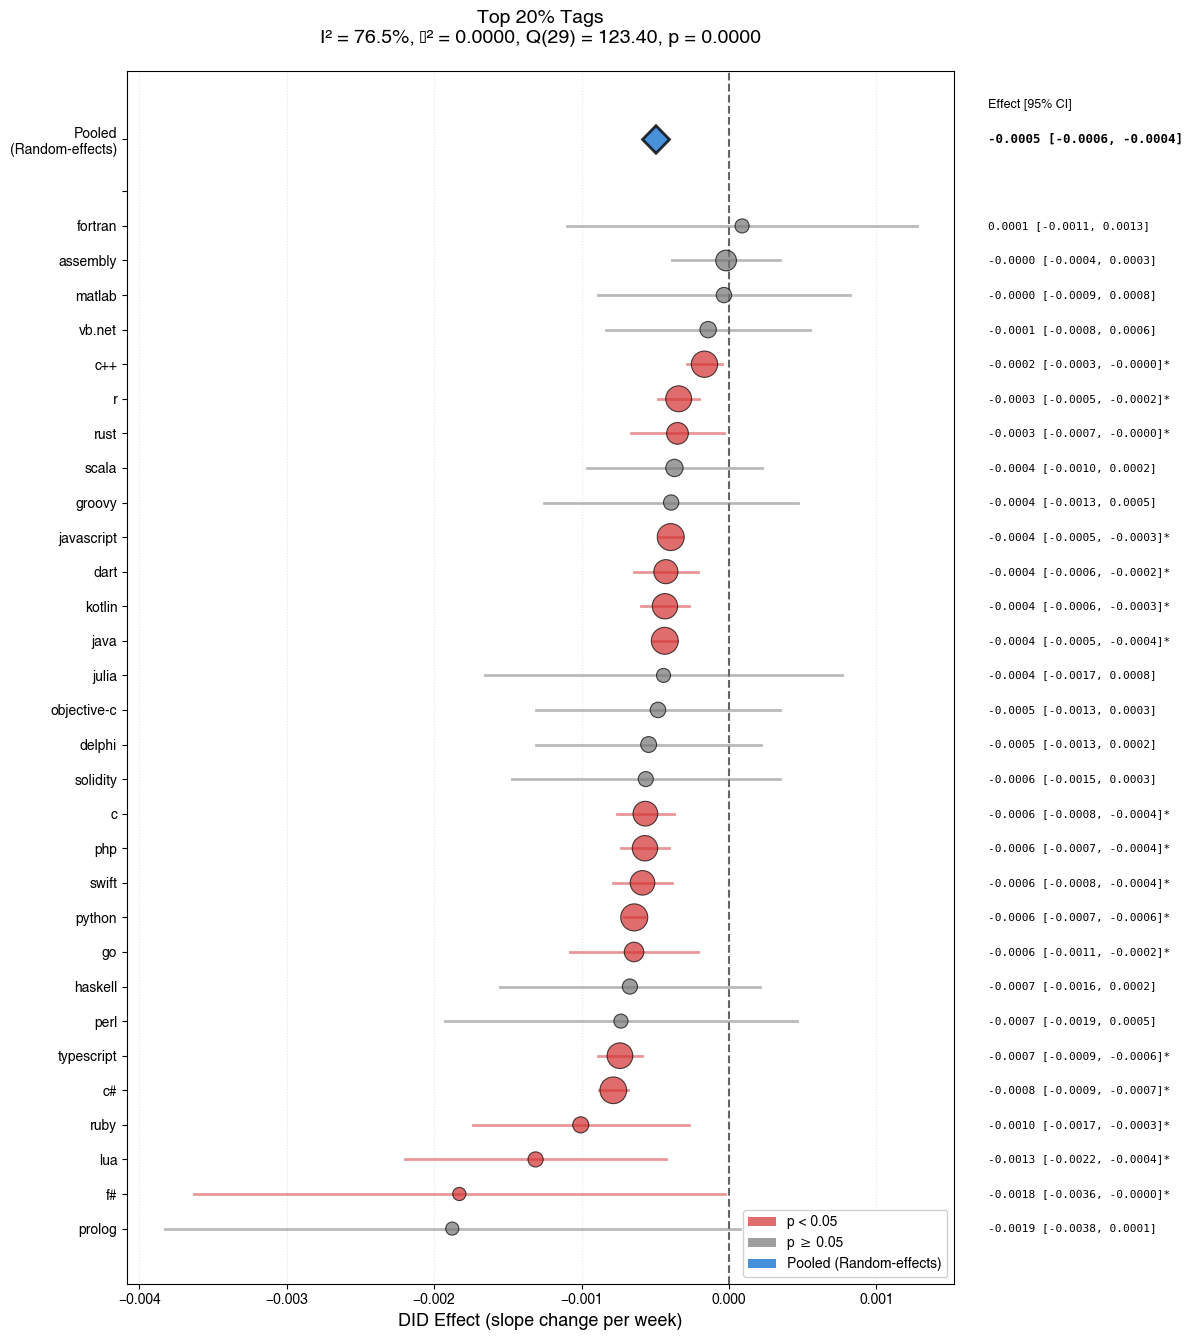

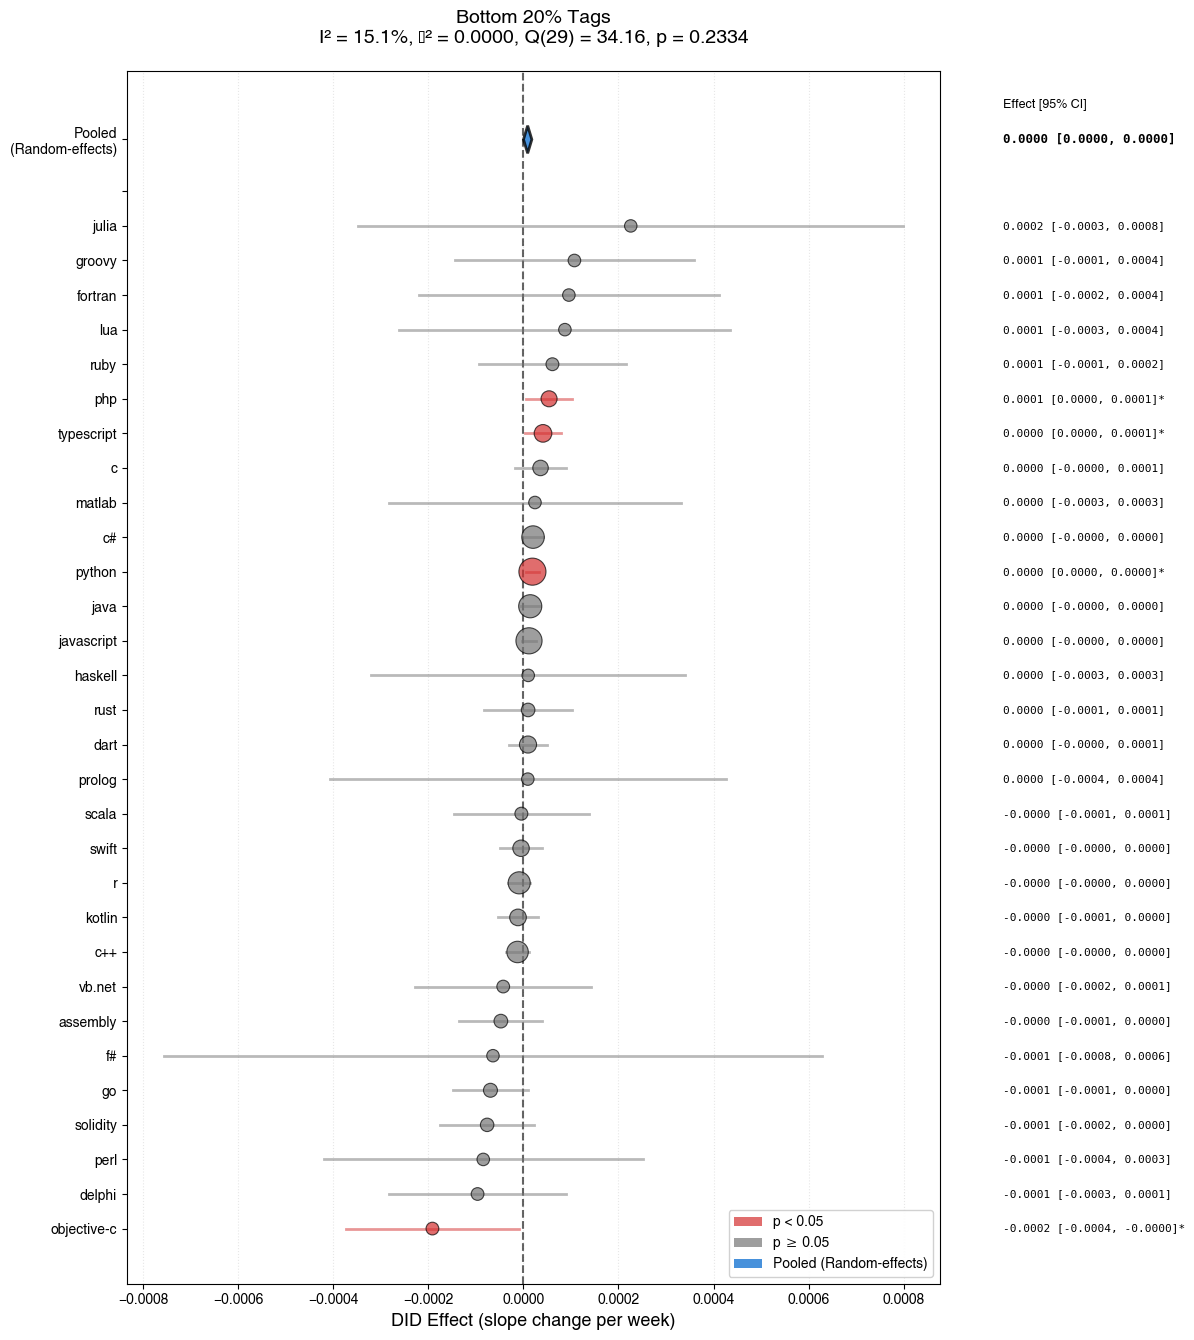

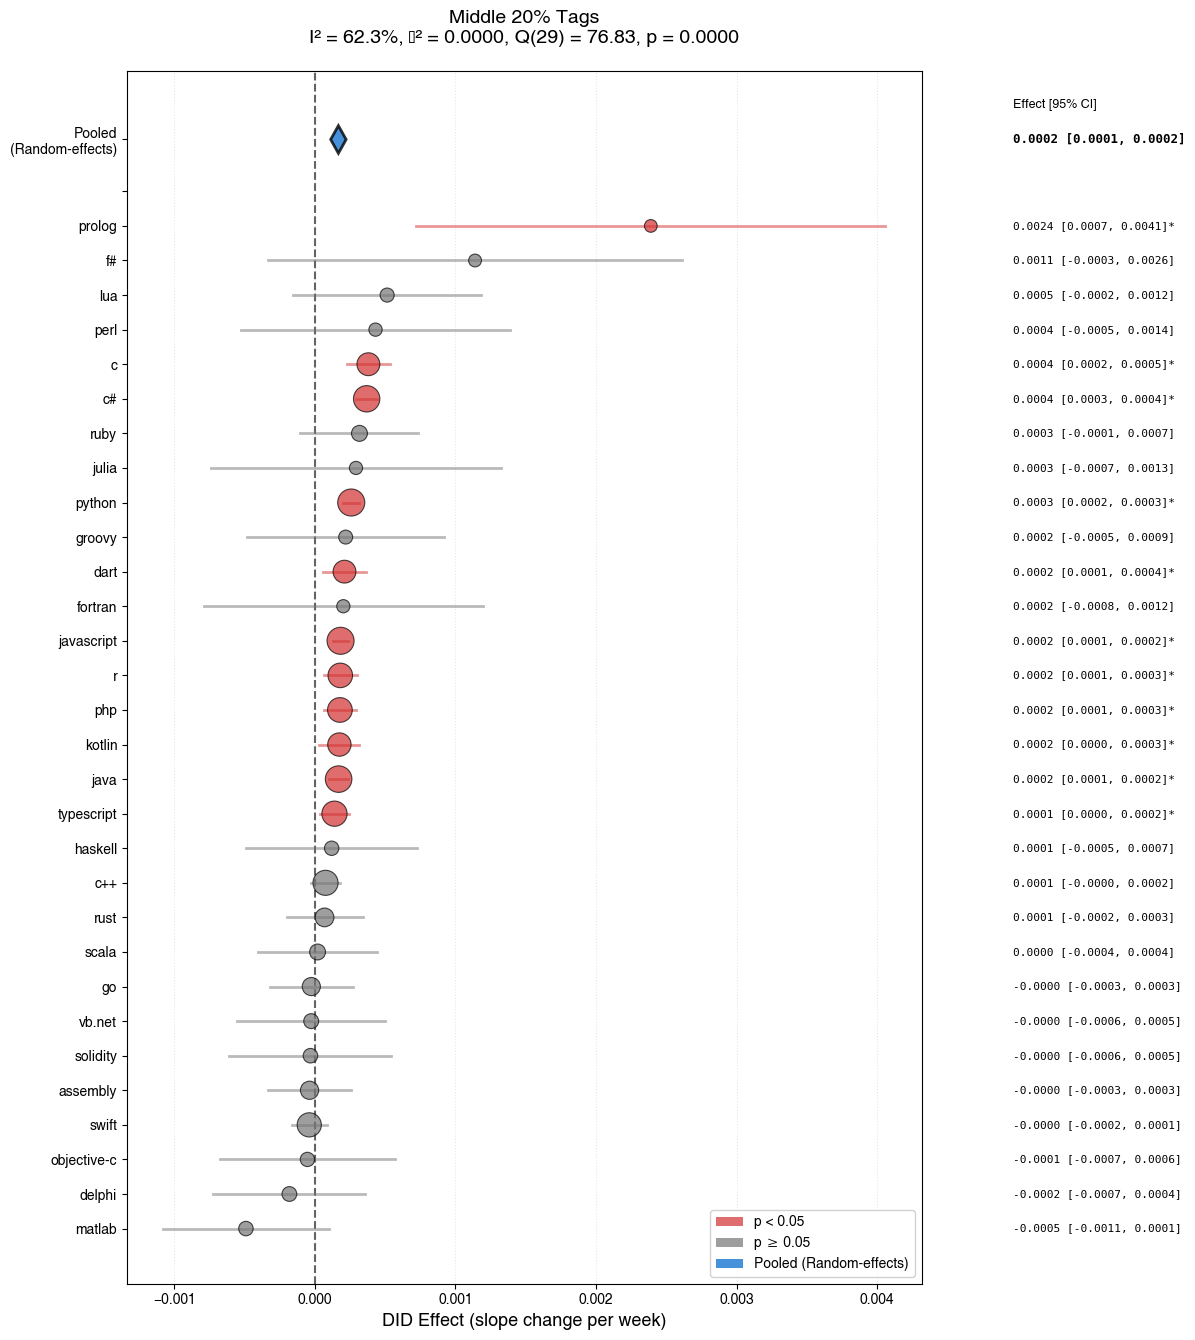

In [17]:
def publication_forest_plot(meta_results, title, save_path=None):
    """
    Science Advances style forest plot
    """
    df = meta_results['individual'].copy()
    df = df.sort_values('effect')
    
    fig, ax = plt.subplots(figsize=(12, max(10, len(df)*0.45)))
    
    y_pos = np.arange(len(df))
    
    # Calculate weights for point sizes
    weights = 1 / (df['var'] + meta_results['tau2'])
    sizes = 80 + 300 * (weights / weights.max())
    
    # Color by significance
    colors = ['#D32F2F' if p < 0.05 else '#757575' for p in df['pvalue']]
    
    # Individual study points
    ax.scatter(df['effect'], y_pos, s=sizes, c=colors, 
              alpha=0.7, edgecolors='black', linewidth=0.8, zorder=3)
    
    # Confidence intervals
    for i, row in enumerate(df.itertuples()):
        color = '#D32F2F' if row.pvalue < 0.05 else '#757575'
        ax.plot([row.ci_lower, row.ci_upper], [i, i],
               color=color, linewidth=2, alpha=0.5, zorder=2)
    
    # Pooled effect (diamond)
    pooled = meta_results['random_effect']
    pooled_se = meta_results['random_se']
    pooled_lower = pooled - 1.96 * pooled_se
    pooled_upper = pooled + 1.96 * pooled_se
    
    diamond_y = len(df) + 1.5
    diamond_x = [pooled_lower, pooled, pooled_upper, pooled]
    diamond_y_coords = [diamond_y, diamond_y+0.4, diamond_y, diamond_y-0.4]
    
    ax.fill(diamond_x, diamond_y_coords, color='#1976D2', 
           alpha=0.8, edgecolor='black', linewidth=2, zorder=4,
           label=f'Pooled (RE): {pooled:.4f} [95% CI]')
    
    # Zero line
    ax.axvline(0, color='black', linestyle='--', 
              linewidth=1.5, alpha=0.6, zorder=1)
    
    # Y-axis labels
    ytick_labels = list(df['language']) + ['', 'Pooled\n(Random-effects)']
    ax.set_yticks(list(y_pos) + [len(df), diamond_y])
    ax.set_yticklabels(ytick_labels, fontsize=10)
    
    # X-axis
    ax.set_xlabel('DID Effect (slope change per week)', 
                 fontsize=13, fontweight='bold')
    ax.set_title(f'{title}\n' + 
                f'I² = {meta_results["I2"]:.1f}%, τ² = {meta_results["tau2"]:.4f}, ' +
                f'Q({len(df)-1}) = {meta_results["Q"]:.2f}, p = {meta_results["Q_pval"]:.4f}',
                fontsize=14, fontweight='bold', pad=20)
    
    # Add statistics text on right
    xlim = ax.get_xlim()
    text_x = xlim[1] * 1.15
    
    for i, row in enumerate(df.itertuples()):
        sig_marker = '*' if row.pvalue < 0.05 else ''
        ax.text(text_x, i, 
               f'{row.effect:.4f} [{row.ci_lower:.4f}, {row.ci_upper:.4f}]{sig_marker}',
               fontsize=8, va='center', ha='left', family='monospace')
    
    ax.text(text_x, diamond_y,
           f'{pooled:.4f} [{pooled_lower:.4f}, {pooled_upper:.4f}]',
           fontsize=9, va='center', ha='left', family='monospace', 
           fontweight='bold')
    
    # Add column header
    ax.text(text_x, len(df)+2.5, 'Effect [95% CI]',
           fontsize=9, va='center', ha='left', fontweight='bold')
    
    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle=':', zorder=0)
    ax.set_axisbelow(True)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#D32F2F', alpha=0.7, label='p < 0.05'),
        Patch(facecolor='#757575', alpha=0.7, label='p ≥ 0.05'),
        Patch(facecolor='#1976D2', alpha=0.8, label='Pooled (Random-effects)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', 
             framealpha=0.9, fontsize=10)
    
    # Adjust layout to fit text
    plt.subplots_adjust(right=0.75)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    return fig

# Create plots
fig1 = publication_forest_plot(meta_top, 'Top 20% Tags', 'forest_top20.png')
fig2 = publication_forest_plot(meta_bot, 'Bottom 20% Tags', 'forest_bot20.png')
fig3 = publication_forest_plot(meta_mid, 'Middle 20% Tags', 'forest_mid20.png')
plt.show()

In [18]:
def create_summary_table(meta_top, meta_bot):
    """
    Summary table for manuscript
    """
    table_data = {
        'Tag Group': ['Top 20%', 'Bottom 20%'],
        'N Languages': [meta_top['n_languages'], meta_bot['n_languages']],
        'Pooled Effect (RE)': [
            f"{meta_top['random_effect']:.4f}",
            f"{meta_bot['random_effect']:.4f}"
        ],
        '95% CI': [
            f"[{meta_top['random_effect']-1.96*meta_top['random_se']:.4f}, "
            f"{meta_top['random_effect']+1.96*meta_top['random_se']:.4f}]",
            f"[{meta_bot['random_effect']-1.96*meta_bot['random_se']:.4f}, "
            f"{meta_bot['random_effect']+1.96*meta_bot['random_se']:.4f}]"
        ],
        'p-value': [
            f"{meta_top['random_p']:.4f}",
            f"{meta_bot['random_p']:.4f}"
        ],
        'I² (%)': [
            f"{meta_top['I2']:.1f}",
            f"{meta_bot['I2']:.1f}"
        ],
        'τ²': [
            f"{meta_top['tau2']:.6f}",
            f"{meta_bot['tau2']:.6f}"
        ],
        'Significant Languages': [
            f"{meta_top['n_significant']}/{meta_top['n_languages']}",
            f"{meta_bot['n_significant']}/{meta_bot['n_languages']}"
        ]
    }
    
    df_table = pd.DataFrame(table_data)
    print("\n" + "="*100)
    print("SUMMARY TABLE FOR MANUSCRIPT")
    print("="*100)
    print(df_table.to_string(index=False))
    print("="*100)
    
    return df_table

summary_table = create_summary_table(meta_top, meta_bot)


SUMMARY TABLE FOR MANUSCRIPT
 Tag Group  N Languages Pooled Effect (RE)             95% CI p-value I² (%)       τ² Significant Languages
   Top 20%           30            -0.0005 [-0.0006, -0.0004]  0.0000   76.5 0.000000                 17/30
Bottom 20%           30             0.0000   [0.0000, 0.0000]  0.0403   15.1 0.000000                  4/30


## top20% vs bottom20%

In [4]:
def did_top_vs_bottom(df_top, df_bot, lang):
    df_top = df_top.copy()
    df_bot = df_bot.copy()
    df_top['treated'] = 1
    df_bot['treated'] = 0
    
    df_combined = pd.concat([df_top, df_bot], axis=0)
    df_combined['post'] = (df_combined['rel_week'] >= 0).astype(int)
    
    model = smf.ols(
        'pct_pct ~ rel_week + post + treated + rel_week:post + rel_week:treated + post:treated + rel_week:post:treated',
        data=df_combined
    ).fit()
    
    # rel_week:post:treated 가 DID 효과
    effect = model.params['rel_week:post:treated']
    se = model.bse['rel_week:post:treated']
    pval = model.pvalues['rel_week:post:treated']
    
    return {
        'language': lang,
        'effect': effect,
        'se': se,
        'pvalue': pval,
        'ci_lower': effect - 1.96 * se,
        'ci_upper': effect + 1.96 * se,
        'n': len(df_combined),
        'significant': pval < 0.05
    }

In [ ]:
def did_top_vs_bottom(df_top, df_bot, lang):
    df_top = df_top.copy()
    df_bot = df_bot.copy()
    df_top['treated'] = 1
    df_bot['treated'] = 0
    
    df_combined = pd.concat([df_top, df_bot], axis=0)
    df_combined['post'] = (df_combined['rel_week'] >= 0).astype(int)
    
    model = smf.ols(
        'pct_pct ~ rel_week + post + treated + rel_week:post + rel_week:treated + post:treated + rel_week:post:treated',
        data=df_combined
    ).fit()
    
    # rel_week:post:treated 가 DID 효과
    effect = model.params['rel_week:post:treated']
    se = model.bse['rel_week:post:treated']
    pval = model.pvalues['rel_week:post:treated']
    
    return {
        'language': lang,
        'effect': effect,
        'se': se,
        'pvalue': pval,
        'ci_lower': effect - 1.96 * se,
        'ci_upper': effect + 1.96 * se,
        'n': len(df_combined),
        'significant': pval < 0.05
    }

def comprehensive_meta_analysis_from_df(df_results, tag_group_name):
    """
    이미 계산된 individual DID 결과로 메타분석 수행
    
    Args:
        df_results: DataFrame with columns ['language', 'effect', 'se', 'pvalue', 
                    'ci_lower', 'ci_upper', 'n', 'significant']
        tag_group_name: str, 분석 그룹 이름 (e.g., 'Top 20% vs Bottom 20% DID')
    
    Returns:
        dict with meta-analysis results
    """
    df_results = df_results.copy()
    df_results['var'] = df_results['se'] ** 2
    
    print(f"\n{'='*70}")
    print(f"{tag_group_name} - META-ANALYSIS RESULTS")
    print(f"{'='*70}\n")
    
    # ── Step 1: Fixed-effect model ──
    weights = 1 / df_results['var']
    fixed_effect = np.sum(df_results['effect'] * weights) / np.sum(weights)
    fixed_se = np.sqrt(1 / np.sum(weights))
    fixed_z = fixed_effect / fixed_se
    fixed_p = 2 * (1 - stats.norm.cdf(abs(fixed_z)))
    
    print("FIXED-EFFECT MODEL:")
    print(f"  Pooled effect: {fixed_effect:.6f} (SE: {fixed_se:.6f})")
    print(f"  95% CI: [{fixed_effect - 1.96*fixed_se:.6f}, {fixed_effect + 1.96*fixed_se:.6f}]")
    print(f"  Z = {fixed_z:.3f}, p = {fixed_p:.4f}")
    
    # ── Step 2: Heterogeneity ──
    Q = np.sum(weights * (df_results['effect'] - fixed_effect)**2)
    df_q = len(df_results) - 1
    Q_pval = 1 - stats.chi2.cdf(Q, df_q) if df_q > 0 else 1.0
    I2 = max(0, 100 * (Q - df_q) / Q) if Q > 0 else 0
    
    if I2 < 25:
        het_interp = "low"
    elif I2 < 50:
        het_interp = "moderate"
    elif I2 < 75:
        het_interp = "substantial"
    else:
        het_interp = "considerable"
    
    print(f"\nHETEROGENEITY:")
    print(f"  Cochran's Q = {Q:.2f} (df = {df_q}, p = {Q_pval:.4f})")
    print(f"  I² = {I2:.1f}% → {het_interp} heterogeneity")
    
    # ── Step 3: Random-effects model (DerSimonian-Laird) ──
    C = np.sum(weights) - np.sum(weights**2) / np.sum(weights)
    tau2 = max(0, (Q - df_q) / C) if C > 0 else 0
    
    random_weights = 1 / (df_results['var'] + tau2)
    random_effect = np.sum(df_results['effect'] * random_weights) / np.sum(random_weights)
    random_se = np.sqrt(1 / np.sum(random_weights))
    random_z = random_effect / random_se
    random_p = 2 * (1 - stats.norm.cdf(abs(random_z)))
    
    print(f"\nRANDOM-EFFECTS MODEL:")
    print(f"  τ² = {tau2:.6f}")
    print(f"  Pooled effect: {random_effect:.6f} (SE: {random_se:.6f})")
    print(f"  95% CI: [{random_effect - 1.96*random_se:.6f}, {random_effect + 1.96*random_se:.6f}]")
    print(f"  Z = {random_z:.3f}, p = {random_p:.4f}")
    
    # ── Step 4: Subgroup analysis ──
    sig_langs = df_results[df_results['significant'] == True]
    nonsig_langs = df_results[df_results['significant'] == False]
    
    print(f"\nSUBGROUP ANALYSIS:")
    print(f"  Significant languages (p<0.05): {len(sig_langs)}/{len(df_results)}")
    if len(sig_langs) > 0:
        print(f"    Mean effect: {sig_langs['effect'].mean():.6f}")
        print(f"    Languages: {', '.join(sig_langs['language'].tolist())}")
    print(f"  Non-significant languages: {len(nonsig_langs)}/{len(df_results)}")
    if len(nonsig_langs) > 0:
        print(f"    Mean effect: {nonsig_langs['effect'].mean():.6f}")
    
    # ── Step 5: Egger's test (publication bias) ──
    if len(df_results) >= 10:
        precision = 1 / df_results['se']
        standard_effect = df_results['effect'] / df_results['se']
        
        egger_model = smf.ols(
            'standard_effect ~ precision',
            data=pd.DataFrame({
                'standard_effect': standard_effect,
                'precision': precision
            })
        ).fit()
        
        egger_intercept = egger_model.params['Intercept']
        egger_p = egger_model.pvalues['Intercept']
        
        print(f"\nEGGER'S TEST (Publication Bias):")
        print(f"  Intercept = {egger_intercept:.4f}, p = {egger_p:.4f}")
        if egger_p < 0.05:
            print(f"  → Evidence of publication bias/small-study effects")
        else:
            print(f"  → No strong evidence of publication bias")
    else:
        egger_intercept = None
        egger_p = None
        print(f"\nEGGER'S TEST: Skipped (need ≥ 10 studies, have {len(df_results)})")
    
    return {
        'individual': df_results,
        'fixed_effect': fixed_effect,
        'fixed_se': fixed_se,
        'fixed_p': fixed_p,
        'random_effect': random_effect,
        'random_se': random_se,
        'random_p': random_p,
        'tau2': tau2,
        'Q': Q,
        'Q_pval': Q_pval,
        'I2': I2,
        'n_languages': len(df_results),
        'n_significant': len(sig_langs)
    }


did_results = []

for idx, lang in enumerate(CONSTANTS.languages_from2020to2022):
    print(f'[Start....] {lang}')
    visualization_target = f'run_id_{100+idx}'
    model_in_run = 'tag'
    viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
    data_dir = f"{viz_dir}/data"
    option_dict = load_json(f"{viz_dir}/option.json")
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    df = load_df(data_dir, ['cdate', 'id', 'tag', 'cnt', 'tot_cnt', 'pct'])
    df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")
    df['rel_week'] = np.floor((df['cdate'] - std_date).dt.days / 7)
    
    proportion_dict = calc_top_mid_bottom_tags_prop(df)
    
    df_top = proportion_dict['Top 20% Tags']
    df_bot = proportion_dict['Bottom 20% Tags']
    # df_mid = proportion_dict['Middle 20% Tags']
    
    try:
        result = did_top_vs_bottom(df_top, df_bot, lang)
        did_results.append(result)
        print(f'  effect={result["effect"]:.6f}, p={result["pvalue"]:.4f}')
    except Exception as e:
        print(f'  Skipped: {e}')
    
    print(f'[End....] {lang}')

# 결과를 DataFrame으로
df_did_results = pd.DataFrame(did_results)

# 메타분석 실행
meta_result = comprehensive_meta_analysis_from_df(df_did_results, 'Top 20% vs Bottom 20% DID')

In [6]:
did_results = []

for idx, lang in enumerate(CONSTANTS.languages_from2020to2022):
    print(f'[Start....] {lang}')
    visualization_target = f'run_id_{100+idx}'
    model_in_run = 'tag'
    viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
    data_dir = f"{viz_dir}/data"
    option_dict = load_json(f"{viz_dir}/option.json")
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    df = load_df(data_dir, ['cdate', 'id', 'tag', 'cnt', 'tot_cnt', 'pct'])
    df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")
    df['rel_week'] = np.floor((df['cdate'] - std_date).dt.days / 7)
    
    proportion_dict = calc_top_mid_bottom_tags_prop(df)
    
    df_top = proportion_dict['Top 20% Tags']
    df_bot = proportion_dict['Bottom 20% Tags']
    # df_mid = proportion_dict['Middle 20% Tags']
    
    try:
        result = did_top_vs_bottom(df_top, df_bot, lang)
        did_results.append(result)
        print(f'  effect={result["effect"]:.6f}, p={result["pvalue"]:.4f}')
    except Exception as e:
        print(f'  Skipped: {e}')
    
    print(f'[End....] {lang}')

# 결과를 DataFrame으로
df_did_results = pd.DataFrame(did_results)

# 메타분석 실행
meta_result = comprehensive_meta_analysis_from_df(df_did_results, 'Top 20% vs Bottom 20% DID')

[Start....] python


  effect=-0.000661, p=0.0000
[End....] python
[Start....] javascript
  effect=-0.000407, p=0.0000
[End....] javascript
[Start....] java
  effect=-0.000450, p=0.0000
[End....] java
[Start....] c#
  effect=-0.000805, p=0.0000
[End....] c#
[Start....] c++
  effect=-0.000154, p=0.0147
[End....] c++
[Start....] c
  effect=-0.000603, p=0.0000
[End....] c
[Start....] r
  effect=-0.000332, p=0.0000
[End....] r
[Start....] php
  effect=-0.000624, p=0.0000
[End....] php
[Start....] swift
  effect=-0.000581, p=0.0000
[End....] swift
[Start....] kotlin
  effect=-0.000423, p=0.0000
[End....] kotlin
[Start....] dart
  effect=-0.000438, p=0.0001
[End....] dart
[Start....] typescript
  effect=-0.000781, p=0.0000
[End....] typescript
[Start....] go
  effect=-0.000575, p=0.0105
[End....] go
[Start....] ruby
  effect=-0.001067, p=0.0054
[End....] ruby
[Start....] rust
  effect=-0.000359, p=0.0341
[End....] rust
[Start....] scala
  effect=-0.000366, p=0.2404
[End....] scala
[Start....] julia
  effect=-0.0

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch


def publication_forest_plot(meta_results, title, save_path=None):
    """
    Science Advances style forest plot for meta-analysis results.
    """
    # ---- Science Advances-ish rcParams ----
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9.5,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    # color palette (matches the language forest plot)
    C_POS = "#C0392B"   # significant & positive-ish (warm red)
    C_NEG = "#2C5F8D"   # significant & negative / non-sig cool
    C_NS  = "#8A8A8A"   # non-significant (muted gray)
    C_POOL = "#1F4E79"  # pooled diamond (deep blue)
    C_REF = "0.55"
    C_GRID = "0.92"

    # ---- data prep ----
    df = meta_results["individual"].copy()
    order_map = {lang: i for i, lang in enumerate(CONSTANTS.languages_from2020to2022)}
    df = df.sort_values(by="language", key=lambda x: x.map(order_map), ascending=False).reset_index(drop=True)

    n = len(df)
    y_pos = np.arange(n)

    # point sizes based on inverse-variance weights
    weights = 1.0 / (df["var"] + meta_results["tau2"])
    w_norm = weights / weights.max()
    smin, smax = 14, 80
    sizes = smin + (smax - smin) * np.sqrt(w_norm)

    # colors by significance and sign
    def _color(pval, eff):
        if pval >= 0.05:
            return C_NS
        return C_POS if eff > 0 else C_NEG
    colors = [_color(r.pvalue, r.effect) for r in df.itertuples()]

    # ---- figure with explicit margins ----
    fig_height = max(6.5, 0.30 * n + 2.6)
    fig = plt.figure(figsize=(6.4, fig_height))
    # [left, bottom, width, height] — no right-side number column anymore
    ax = fig.add_axes([0.22, 0.13, 0.74, 0.78])

    # ---- zero reference line ----
    ax.axvline(0, color=C_REF, lw=0.6, ls="--", zorder=0)

    # ---- CI bars ----
    for i, row in enumerate(df.itertuples()):
        ax.plot([row.ci_lower, row.ci_upper], [i, i],
                color=colors[i], lw=1.0, alpha=0.85,
                solid_capstyle="round", zorder=2)

    # ---- points ----
    ax.scatter(df["effect"], y_pos, s=sizes, c=colors,
               edgecolor="white", linewidth=0.5, zorder=3)

    # ---- pooled effect (diamond) ----
    pooled = meta_results["random_effect"]
    pooled_se = meta_results["random_se"]
    pooled_lo = pooled - 1.96 * pooled_se
    pooled_hi = pooled + 1.96 * pooled_se

    diamond_y = n + 1.0
    diamond_half = 0.35
    diamond_x = [pooled_lo, pooled, pooled_hi, pooled]
    diamond_y_coords = [diamond_y, diamond_y + diamond_half,
                        diamond_y, diamond_y - diamond_half]
    ax.fill(diamond_x, diamond_y_coords, color=C_POOL,
            alpha=0.9, edgecolor="white", linewidth=0.8, zorder=4)

    # ---- y-axis ----
    ytick_labels = list(df["language"]) + ["Pooled (RE)"]
    ytick_positions = list(y_pos) + [diamond_y]
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels)
    ax.get_yticklabels()[-1].set_fontweight("bold")
    ax.set_ylim(-0.8, diamond_y + 1.0)

    # ---- x-axis ----
    ax.set_xlabel("DID effect (slope change per week)", labelpad=6)

    # ---- title ----
    ax.set_title(title, loc="left", fontweight="bold", pad=12)

    # ---- style ----
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", lw=0.4, color=C_GRID, zorder=0)
    ax.set_axisbelow(True)

    # ---- legend (upper-left inside the plot) ----
    legend_elements = [
        Patch(facecolor=C_POS, label="p < 0.05, positive"),
        Patch(facecolor=C_NEG, label="p < 0.05, negative"),
        Patch(facecolor=C_NS,  label="p ≥ 0.05"),
        Patch(facecolor=C_POOL, label="Pooled (random-effects)"),
    ]
    ax.legend(handles=legend_elements, loc="upper left",
              bbox_to_anchor=(0.01, 0.99),
              fontsize=6.8, labelspacing=0.6,
              borderpad=0.6, handletextpad=0.6)

    # ---- caption (with heterogeneity statistics) ----
    caption = (
        f"Random-effects meta-analysis across {n} languages.  "
        f"Heterogeneity: I² = {meta_results['I2']:.1f}%, "
        f"τ² = {meta_results['tau2']:.4f}, "
        f"Q({n-1}) = {meta_results['Q']:.2f}, "
        f"p = {meta_results['Q_pval']:.4f}.  "
        f"Error bars: 95% CI.  Point size ∝ √(inverse-variance weight).  "
        f"Blue diamond: pooled random-effects estimate."
    )
    fig.text(0.04, 0.015, caption,
             fontsize=6.2, color="0.35",
             ha="left", va="bottom", wrap=True)

    # ---- save ----
    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches=None)
        if save_path.endswith(".pdf"):
            fig.savefig(save_path.replace(".pdf", ".png"), dpi=600, bbox_inches=None)
            fig.savefig(save_path.replace(".pdf", ".svg"), bbox_inches=None)

    return fig

In [15]:
meta_result

{'individual':        language    effect        se        pvalue  ci_lower  ci_upper    n  \
 0        python -0.000661  0.000038  2.322344e-54 -0.000735 -0.000588  520   
 1    javascript -0.000407  0.000041  6.209668e-21 -0.000488 -0.000325  520   
 2          java -0.000450  0.000043  1.407144e-23 -0.000533 -0.000366  520   
 3            c# -0.000805  0.000052  3.922918e-45 -0.000906 -0.000704  520   
 4           c++ -0.000154  0.000063  1.468783e-02 -0.000277 -0.000031  520   
 5             c -0.000603  0.000101  4.509131e-09 -0.000801 -0.000405  520   
 6             r -0.000332  0.000071  4.128127e-06 -0.000472 -0.000192  520   
 7           php -0.000624  0.000086  1.897116e-12 -0.000793 -0.000454  520   
 8         swift -0.000581  0.000103  3.093085e-08 -0.000784 -0.000379  520   
 9        kotlin -0.000423  0.000087  1.431324e-06 -0.000592 -0.000253  520   
 10         dart -0.000438  0.000113  1.188845e-04 -0.000659 -0.000216  520   
 11   typescript -0.000781  0.000079  

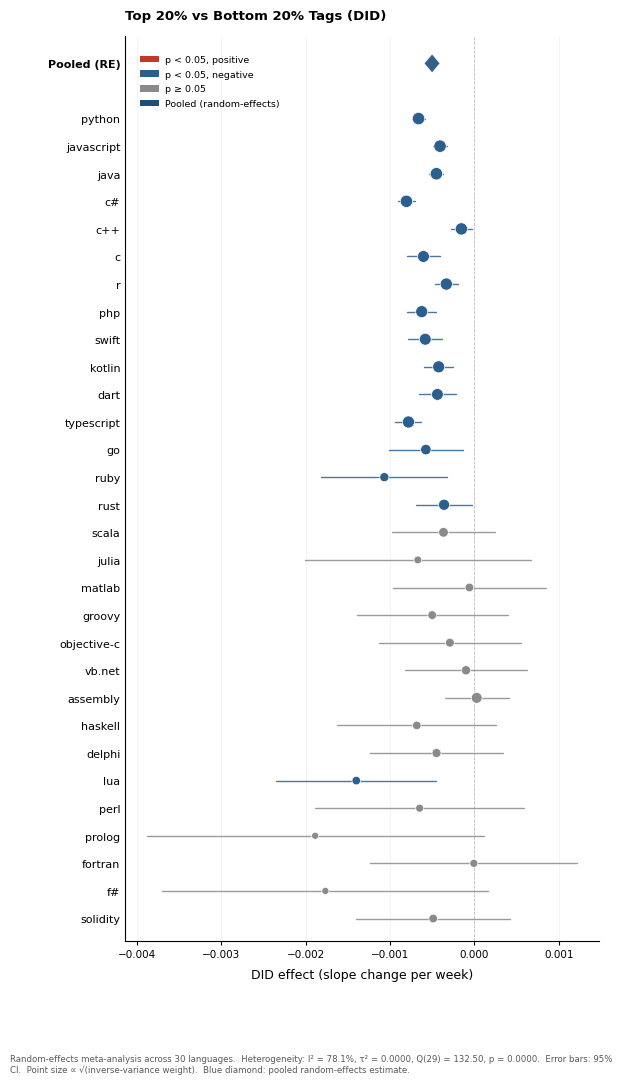

In [16]:
# 변경: 1개 플롯
fig = publication_forest_plot(
    meta_result, 
    'Top 20% vs Bottom 20% Tags (DID)', 
    'forest_did_top_vs_bottom.png'
)
plt.show()

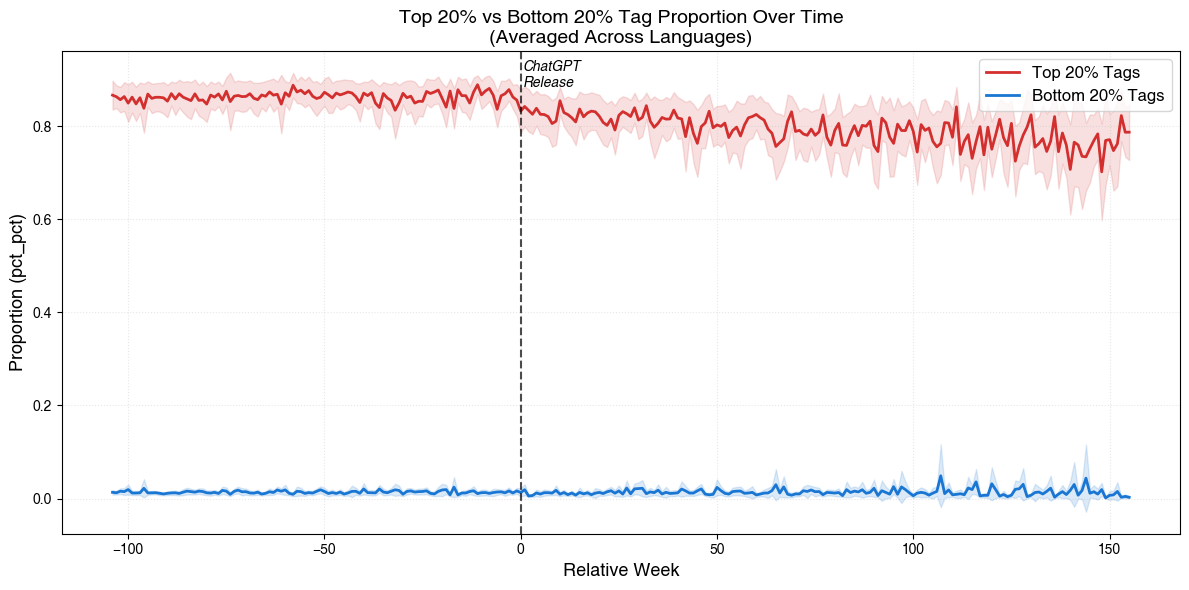

In [23]:
def plot_top_vs_bottom_timeseries(tot_top_df, tot_bot_df, std_date, save_path=None):
    """
    Top 20% vs Bottom 20% 비중 추이 시계열 그래프
    """
    # 전체 언어 평균
    top_avg = tot_top_df.groupby('rel_week')['pct_pct'].mean().reset_index()
    bot_avg = tot_bot_df.groupby('rel_week')['pct_pct'].mean().reset_index()
    
    # 신뢰구간용 표준오차
    top_se = tot_top_df.groupby('rel_week')['pct_pct'].sem().reset_index(name='se')
    bot_se = tot_bot_df.groupby('rel_week')['pct_pct'].sem().reset_index(name='se')
    
    top_avg = top_avg.merge(top_se, on='rel_week')
    bot_avg = bot_avg.merge(bot_se, on='rel_week')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Top 20%
    ax.plot(top_avg['rel_week'], top_avg['pct_pct'], 
            color='#D32F2F', linewidth=2, label='Top 20% Tags')
    ax.fill_between(top_avg['rel_week'], 
                     top_avg['pct_pct'] - 1.96 * top_avg['se'],
                     top_avg['pct_pct'] + 1.96 * top_avg['se'],
                     color='#D32F2F', alpha=0.15)
    
    # Bottom 20%
    ax.plot(bot_avg['rel_week'], bot_avg['pct_pct'], 
            color='#1976D2', linewidth=2, label='Bottom 20% Tags')
    ax.fill_between(bot_avg['rel_week'], 
                     bot_avg['pct_pct'] - 1.96 * bot_avg['se'],
                     bot_avg['pct_pct'] + 1.96 * bot_avg['se'],
                     color='#1976D2', alpha=0.15)
    
    # ChatGPT 출시 시점 (rel_week = 0)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(0.5, ax.get_ylim()[1] * 0.98, 'ChatGPT\nRelease', 
            fontsize=10, ha='left', va='top', fontstyle='italic')
    
    ax.set_xlabel('Relative Week', fontsize=13, fontweight='bold')
    ax.set_ylabel('Proportion (pct_pct)', fontsize=13, fontweight='bold')
    ax.set_title('Top 20% vs Bottom 20% Tag Proportion Over Time\n(Averaged Across Languages)', 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=12, loc='best')
    ax.grid(alpha=0.3, linestyle=':')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

fig = plot_top_vs_bottom_timeseries(tot_top_df, tot_bot_df, std_date, 
                                     save_path='timeseries_top_vs_bottom.png')
plt.show()

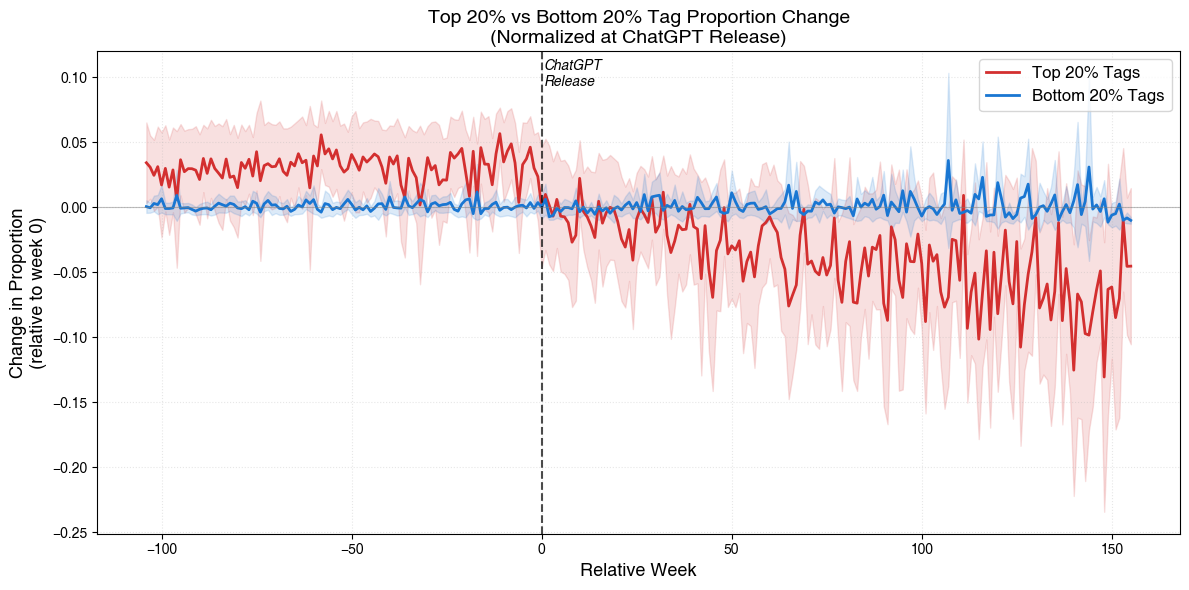

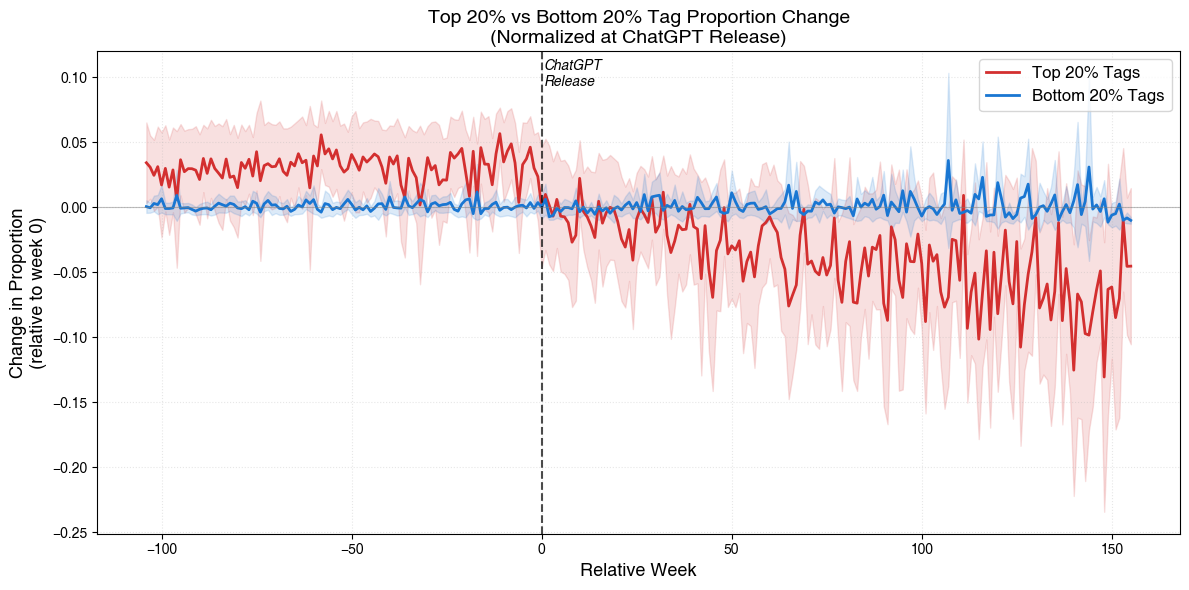

In [26]:
plot_top_vs_bottom_normalized(tot_top_df, tot_bot_df, save_path=None)

## Event study

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

def run_event_study(df):
    df = df.copy()
    
    # treated / control 설정
    df['treated'] = df['group'].map({'top': 1, 'bottom': 0})
    
    # rel_week를 categorical로
    df['rel_week'] = df['rel_week'].astype(int)
    
    # 기준 시점 (보통 -1 추천)
    df['rel_week'] = df['rel_week'].astype('category')
    df['rel_week'] = df['rel_week'].cat.reorder_categories(
        sorted(df['rel_week'].unique()), ordered=True
    )
    
    # 모델
    model = smf.ols(
        'pct_pct ~ C(rel_week) * treated',
        data=df
    ).fit()
    
    results = []
    
    for week in df['rel_week'].cat.categories:
        if week == -1:
            continue  # baseline
        
        term = f'C(rel_week)[T.{week}]:treated'
        
        if term in model.params:
            coef = model.params[term]
            se = model.bse[term]
            
            results.append({
                'rel_week': week,
                'effect': coef,
                'se': se,
                'ci_lower': coef - 1.96 * se,
                'ci_upper': coef + 1.96 * se,
                'pvalue': model.pvalues[term]
            })
    
    return pd.DataFrame(results)

In [ ]:
did_results = []

for idx, lang in enumerate(CONSTANTS.languages_from2020to2022):
    print(f'[Start....] {lang}')
    visualization_target = f'run_id_{100+idx}'
    model_in_run = 'tag'
    viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
    data_dir = f"{viz_dir}/data"
    option_dict = load_json(f"{viz_dir}/option.json")
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    df = load_df(data_dir, ['cdate', 'id', 'tag', 'cnt', 'tot_cnt', 'pct'])
    df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")
    df['rel_week'] = np.floor((df['cdate'] - std_date).dt.days / 7)
    
    proportion_dict = calc_top_mid_bottom_tags_prop(df)
    
    df_top = proportion_dict['Top 20% Tags']
    df_bot = proportion_dict['Bottom 20% Tags']
    # df_mid = proportion_dict['Middle 20% Tags']
    
    try:
        result = did_top_vs_bottom(df_top, df_bot, lang)
        did_results.append(result)
        print(f'  effect={result["effect"]:.6f}, p={result["pvalue"]:.4f}')
    except Exception as e:
        print(f'  Skipped: {e}')
    
    print(f'[End....] {lang}')

# 결과를 DataFrame으로
df_did_results = pd.DataFrame(did_results)

# 메타분석 실행
meta_result = comprehensive_meta_analysis_from_df(df_did_results, 'Top 20% vs Bottom 20% DID')

NameError: name 'Patch' is not defined

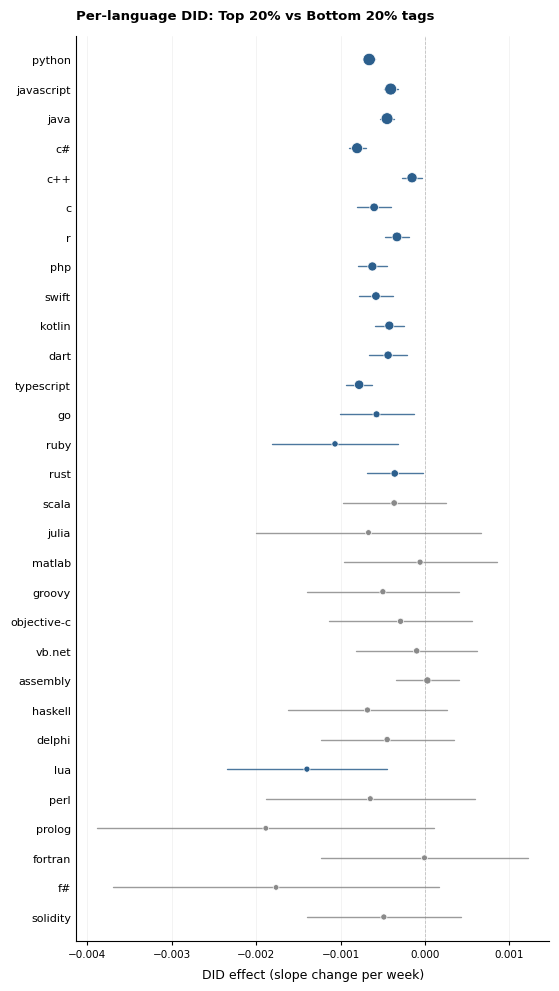

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


# =============================================================
# 1) 언어 하나에 대한 DID 분석
# =============================================================
def did_top_vs_bottom(df_top, df_bot, lang):
    """
    한 언어 안에서 top 20% 태그 vs bottom 20% 태그의
    추세 변화 차이를 triple-interaction DID로 추정.
    
    rel_week:post:treated 계수 = 기준일 이후 상위 태그의 기울기 변화가
                                  하위 태그의 기울기 변화보다 얼마나 더/덜 큰가
    """
    df_top = df_top.copy()
    df_bot = df_bot.copy()
    df_top["treated"] = 1
    df_bot["treated"] = 0

    df_combined = pd.concat([df_top, df_bot], axis=0)
    df_combined["post"] = (df_combined["rel_week"] >= 0).astype(int)

    model = smf.ols(
        "pct_pct ~ rel_week + post + treated "
        "+ rel_week:post + rel_week:treated + post:treated "
        "+ rel_week:post:treated",
        data=df_combined,
    ).fit()

    key = "rel_week:post:treated"
    effect = model.params[key]
    se = model.bse[key]
    pval = model.pvalues[key]

    return {
        "language": lang,
        "effect": effect,
        "se": se,
        "pvalue": pval,
        "ci_lower": effect - 1.96 * se,
        "ci_upper": effect + 1.96 * se,
        "n": len(df_combined),
        "significant": pval < 0.05,
    }


# =============================================================
# 2) 언어별 DID 반복 실행
# =============================================================
def run_per_language_did(languages):
    """각 언어에 대해 DID를 돌리고 결과 DataFrame 반환."""
    results = []
    for idx, lang in enumerate(languages):
        print(f"[Start] {lang}")
        visualization_target = f"run_id_{100 + idx}"
        model_in_run = "tag"
        viz_dir = (f"{path_list['data_root_dir']}/result/"
                   f"{model_in_run}/{visualization_target}")
        data_dir = f"{viz_dir}/data"
        option_dict = load_json(f"{viz_dir}/option.json")
        std_date = Date_Setting[option_dict["year_range"]]["std_date"]

        df = load_df(data_dir, ["cdate", "id", "tag", "cnt", "tot_cnt", "pct"])
        df["cdate"] = pd.to_datetime(df["cdate"], format="%Y-%m-%d")
        df["rel_week"] = np.floor((df["cdate"] - std_date).dt.days / 7)

        proportion_dict = calc_top_mid_bottom_tags_prop(df)
        df_top = proportion_dict["Top 20% Tags"]
        df_bot = proportion_dict["Bottom 20% Tags"]

        try:
            result = did_top_vs_bottom(df_top, df_bot, lang)
            results.append(result)
            print(f"  effect={result['effect']:.6f}, "
                  f"p={result['pvalue']:.4f}")
        except Exception as e:
            print(f"  Skipped: {e}")
        print(f"[End] {lang}\n")

    return pd.DataFrame(results)


# =============================================================
# 3) 결과 테이블 보기 좋게 출력
# =============================================================
def print_results_table(df_results):
    """언어별 DID 결과를 보기 좋게 출력."""
    print("\n" + "=" * 78)
    print("PER-LANGUAGE DID RESULTS")
    print("=" * 78)
    print(f"{'Language':<20} {'Effect':>10} {'95% CI':>24} "
          f"{'p-value':>10} {'sig':>5}")
    print("-" * 78)

    # effect 기준 정렬 (가장 강한 음의 효과부터)
    df_sorted = df_results.sort_values("effect")
    for _, row in df_sorted.iterrows():
        ci_str = f"[{row['ci_lower']:+.4f}, {row['ci_upper']:+.4f}]"
        sig = "★" if row["significant"] else ""
        print(f"{row['language']:<20} {row['effect']:+10.6f} "
              f"{ci_str:>24} {row['pvalue']:>10.4f} {sig:>5}")
    print("-" * 78)
    print(f"Total: {len(df_results)} languages, "
          f"{df_results['significant'].sum()} significant (p<0.05)")


# =============================================================
# 4) Forest plot (핵심 시각화)
# =============================================================
def did_forest_plot(df_results, title, 
                     order_list=None, save_path=None):
    """
    Science Advances style forest plot for per-language DID results.
    
    Args:
        df_results: DataFrame with columns 
                    [language, effect, se, pvalue, ci_lower, ci_upper, significant]
        title: plot title
        order_list: optional list of language names defining display order
                    (top to bottom); defaults to effect-sorted
        save_path: output path (png/pdf/svg)
    """
    # ---- Science Advances-ish rcParams ----
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9.5,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    # ---- color palette (matched to publication_forest_plot) ----
    C_POS = "#C0392B"   # significant & positive (warm red)
    C_NEG = "#2C5F8D"   # significant & negative (cool blue)
    C_NS  = "#8A8A8A"   # non-significant (muted gray)
    C_REF = "0.55"
    C_GRID = "0.92"

    # ---- data prep ----
    df = df_results.copy()
    
    if order_list is not None:
        order_map = {lang: i for i, lang in enumerate(order_list)}
        df = df.sort_values(
            by="language",
            key=lambda x: x.map(order_map),
            ascending=False,
        ).reset_index(drop=True)
    else:
        df = df.sort_values("effect", ascending=False).reset_index(drop=True)

    n = len(df)
    y_pos = np.arange(n)

    # point sizes based on inverse-variance (1 / se^2)
    var = df["se"] ** 2
    weights = 1.0 / var
    w_norm = weights / weights.max()
    smin, smax = 14, 80
    sizes = smin + (smax - smin) * np.sqrt(w_norm)

    # colors by significance and sign
    def _color(pval, eff):
        if pval >= 0.05:
            return C_NS
        return C_POS if eff > 0 else C_NEG

    colors = [_color(r.pvalue, r.effect) for r in df.itertuples()]

    # ---- figure with explicit margins ----
    fig_height = max(6.5, 0.30 * n + 2.6)
    fig = plt.figure(figsize=(6.4, fig_height))
    ax = fig.add_axes([0.22, 0.13, 0.74, 0.78])

    # ---- zero reference line ----
    ax.axvline(0, color=C_REF, lw=0.6, ls="--", zorder=0)

    # ---- CI bars ----
    for i, row in enumerate(df.itertuples()):
        ax.plot(
            [row.ci_lower, row.ci_upper], [i, i],
            color=colors[i], lw=1.0, alpha=0.85,
            solid_capstyle="round", zorder=2,
        )

    # ---- points ----
    ax.scatter(
        df["effect"], y_pos,
        s=sizes, c=colors,
        edgecolor="white", linewidth=0.5, zorder=3,
    )

    # ---- y-axis ----
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["language"])
    ax.set_ylim(-0.8, n - 0.2)

    # ---- x-axis ----
    ax.set_xlabel("DID effect (slope change per week)", labelpad=6)

    # ---- title ----
    ax.set_title(title, loc="left", fontweight="bold", pad=12)

    # ---- style ----
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", lw=0.4, color=C_GRID, zorder=0)
    ax.set_axisbelow(True)

    # ---- legend (upper-left inside the plot) ----
    legend_elements = [
        Patch(facecolor=C_POS, label="p < 0.05, positive"),
        Patch(facecolor=C_NEG, label="p < 0.05, negative"),
        Patch(facecolor=C_NS,  label="p ≥ 0.05"),
    ]
    ax.legend(
        handles=legend_elements, loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        fontsize=6.8, labelspacing=0.6,
        borderpad=0.6, handletextpad=0.6,
    )

    # ---- caption (no meta-analysis stats) ----
    n_sig = int(df["significant"].sum())
    caption = (
        f"Per-language DID analysis across {n} languages "
        f"({n_sig} significant at p < 0.05).  "
        f"Error bars: 95% CI.  Point size ∝ √(inverse-variance weight).  "
        f"Outcome: slope change of top-20% tags relative to bottom-20% tags "
        f"after the reference date."
    )
    fig.text(
        0.04, 0.015, caption,
        fontsize=6.2, color="0.35",
        ha="left", va="bottom", wrap=True,
    )

    # ---- save ----
    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches=None)
        if save_path.endswith(".pdf"):
            fig.savefig(
                save_path.replace(".pdf", ".png"),
                dpi=600, bbox_inches=None,
            )
            fig.savefig(
                save_path.replace(".pdf", ".svg"),
                bbox_inches=None,
            )

    return fig


# =============================================================
# 사용 예
# =============================================================
# df_did_results는 앞서 run_per_language_did()로 얻은 결과
fig = did_forest_plot(
    df_did_results,
    title="Per-language DID: Top 20% vs Bottom 20% tags",
    order_list=CONSTANTS.languages_from2020to2022,  # 선택: 고정 순서
    save_path="did_forest_plot.pdf",
)
plt.show()


# =============================================================
# 5) 실행
# =============================================================
df_did_results = run_per_language_did(CONSTANTS.languages_from2020to2022)

# 결과 테이블 출력
print_results_table(df_did_results)

# Forest plot
did_forest_plot(
    df_did_results,
    title="Per-language DID: Top 20% vs Bottom 20% tags",
    save_path="did_forest_plot.png",
)